## Customer Sales Analysis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore')

In [2]:
# load dataset
Customer = pd.read_csv(r"C:\Users\dell\Downloads\messy_customer_sales_data.csv")

In [3]:
# read first 5 rows
Customer.head()

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,m,52.0,KOLKATA,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,M,51.0 years,NaN,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india
2,CUST3754,Brittney Martinez,F,62.0,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,FEMALE,40.0,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india
4,CUST5683,Matthew Carroll,f,41.0,CHENNAI,2024-04-05,2024-12-15,NaN,8.0,denise84@example.org,2665569480,India


In [4]:
#Last 5 rows
Customer.tail()

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
10195,CUST10767,Robert Lewis,female,35.0 years,delhi,2020-12-08,2025-01-25,24167.0,9.0,barrycrane@example.net,5004696571,InDia
10196,NaN,Diane Evans,M,53.0,bangalore,2023-12-31,2025-05-07,11639.0,7.0,lisadennis@example.net,5200349941,IND
10197,CUST6315,Joshua Martinez,m,25.0,hyderabad,2022-02-15,2025-01-11,43832.0,2.0,kelli74@example.org,8147428496,India
10198,CUST4812,Sarah Miller,FEMALE,55.0,NaN,2021-03-16,2025-05-14,18827.0,10.0,dawn84@example.org,2987564247,InDia
10199,CUST6588,David Potter,female,34.0,HYDERABAD,2020-10-12,2025-06-27,35211.0,10.0,kochjonathan@example.org,1926206725,India


In [5]:
# information of Customer Data
Customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         9177 non-null   object 
 1   Name                10200 non-null  object 
 2   Gender              9174 non-null   object 
 3   Age                 9249 non-null   object 
 4   City                9184 non-null   object 
 5   Signup_Date         10200 non-null  object 
 6   Last_Purchase_Date  9188 non-null   object 
 7   Purchase_Amount     9179 non-null   float64
 8   Feedback_Score      9177 non-null   float64
 9   Email               10200 non-null  object 
 10  Phone_Number        10200 non-null  int64  
 11  Country             9468 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 956.4+ KB


In [6]:
# Number of shape 
print(Customer.shape)

(10200, 12)


**Data Cleaning & Preparing Process**

In [7]:
CustomerClean = Customer.copy()

In [8]:
# NULl SUmmary
Num = CustomerClean.isnull().sum() 
percentage = round((CustomerClean.isnull().sum())/len(CustomerClean)*100,2)
Datatypes = CustomerClean.dtypes
NullSummary = pd.DataFrame({'NUllNumber':Num, 'Percentages':percentage, 'DataTypes': Datatypes,
'Duplicated': CustomerClean.duplicated().sum()})
NullSummary

,NUllNumber,Percentages,DataTypes,Duplicated
Customer_ID,1023,10.03,object,15
Name,0,0.00,object,15
Gender,1026,10.06,object,15
Age,951,9.32,object,15
City,1016,9.96,object,15
Signup_Date,0,0.00,object,15
Last_Purchase_Date,1012,9.92,object,15
Purchase_Amount,1021,10.01,float64,15
Feedback_Score,1023,10.03,float64,15
Email,0,0.00,object,15


In [9]:
for col in CustomerClean.columns:
    if CustomerClean[col].nunique()<20:
         print(CustomerClean[col].value_counts())
         print('-'*50)

Gender
f         1184
M         1171
m         1163
F         1157
MALE      1131
female    1128
male      1121
FEMALE    1119
Name: count, dtype: int64
--------------------------------------------------
City
Kolkata       820
Mumbai        812
Chennai       784
Bangalore     773
Hyderabad     770
Delhi         763
CHENNAI       404
KOLKATA       395
MUMBAI        393
hyderabad     384
bangalore     383
DELHI         378
delhi         369
BANGALORE     363
HYDERABAD     360
mumbai        352
chennai       343
kolkata       338
Name: count, dtype: int64
--------------------------------------------------
Feedback_Score
2.0     952
4.0     947
7.0     938
6.0     927
3.0     913
8.0     912
1.0     907
9.0     903
10.0    901
5.0     877
Name: count, dtype: int64
--------------------------------------------------
Country
India    7132
IND       793
india     772
InDia     771
Name: count, dtype: int64
--------------------------------------------------


In [10]:
#handling missing values
CustomerClean.dropna(subset=['Customer_ID'],inplace=True)
CustomerClean.shape

(9177, 12)

In [11]:
#handling Age Columns
CustomerClean['Age'].unique()

array(['52.0', '51.0 years', '62.0', '40.0', '41.0', nan, '18.0',
       '43.0 years', '40.0 years', '26.0', '32.0', '22.0', '59.0', '65.0',
       '61.0', '31.0', '54.0 years', '55.0', '69.0', '61.0 years', '24.0',
       '63.0', '19.0', '50.0', '56.0', '36.0', '68.0', '43.0', '38.0',
       '27.0', '57.0 years', '23.0', '25.0', '66.0', '28.0', '30.0',
       '46.0', '48.0', '20.0', '37.0', '67.0', '51.0', '35.0', '58.0',
       '29.0', 'nan years', '39.0', '49.0', '47.0', '42.0', '44.0',
       '64.0', '53.0', '60.0', '59.0 years', '45.0', '21.0', '34.0',
       '54.0', '48.0 years', '46.0 years', '33.0', '57.0', '30.0 years',
       '58.0 years', '35.0 years', '34.0 years', '69.0 years', '250',
       '19.0 years', '27.0 years', '53.0 years', '65.0 years',
       '66.0 years', '44.0 years', '49.0 years', '25.0 years',
       '23.0 years', '62.0 years', '41.0 years', '33.0 years',
       '28.0 years', '22.0 years', '20.0 years', '42.0 years',
       '45.0 years', '3', '63.0 years', '

In [12]:
CustomerClean["Age"] = (
    CustomerClean["Age"]
    .astype(str)
    .str.replace(r"\.0|\s*years", "", regex=True)
)
CustomerClean['Age'] = CustomerClean['Age'].str.strip()
CustomerAge = CustomerClean[(CustomerClean['Age'] != 'nan') & (CustomerClean['Age'].notna())]['Age']
agemedian = int(CustomerAge.astype('int64').median())
CustomerClean["Age"].replace('nan', agemedian, inplace=True)
CustomerClean['Age'] = CustomerClean['Age'].astype('int64')

In [13]:
CustomerClean["Purchase_Amount"].fillna(CustomerClean["Purchase_Amount"].median(),inplace=True)
CatCols = ["Feedback_Score",'Gender','City','Country']
for col in CatCols:
    CustomerClean[col].fillna(CustomerClean[col].mode()[0], inplace=True)
CustomerClean['Last_Purchase_Date'].ffill(inplace=True)    

In [14]:
CustomerClean['City'] = CustomerClean['City'].str.strip().str.capitalize()
CustomerClean['Gender'] = CustomerClean['Gender'].replace({'m ':'Male', 'M':'Male','F':'Female','f ': 'Female'})
CustomerClean['Gender'] = CustomerClean['Gender'].str.capitalize()
CustomerClean['Country'].replace({'IND' : 'India'},inplace=True)
CustomerClean['Country'] = CustomerClean['Country'].str.capitalize()

In [15]:
CustomerClean['Last_Purchase_Date'] = pd.to_datetime(CustomerClean['Last_Purchase_Date'], errors = 'coerce')
CustomerClean['Signup_Date'] = pd.to_datetime(CustomerClean['Signup_Date'], errors = 'coerce')

In [16]:
CustomerClean['Country'].value_counts()

Country
India    9177
Name: count, dtype: int64

In [17]:
#drop duplicate records
CustomerClean = CustomerClean.drop_duplicates(keep='first')

In [18]:
CustomerClean.drop_duplicates(subset = ['Customer_ID'], keep = 'first', inplace=True)

In [19]:
CustomerClean.describe()

,Age,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Phone_Number
count,9000.000000,9000,9000,9.000000e+03,9000.000000,9.000000e+03
mean,43.577667,2023-04-12 05:12:00,2025-04-08 11:45:16.800000,2.908195e+04,5.138222,4.983041e+09
min,-10.000000,2020-10-08 00:00:00,2024-10-08 00:00:00,-5.000000e+02,1.000000,9.208990e+05
25%,32.000000,2022-01-17 18:00:00,2025-01-07 00:00:00,1.383000e+04,2.000000,2.449808e+09
50%,43.000000,2023-04-05 00:00:00,2025-04-10 00:00:00,2.426800e+04,5.000000,4.998591e+09
75%,55.000000,2024-07-12 00:00:00,2025-07-08 06:00:00,3.567125e+04,8.000000,7.510124e+09
max,250.000000,2025-10-08 00:00:00,2025-10-08 00:00:00,9.999999e+06,10.000000,9.994402e+09
std,15.341697,NaN,NaN,2.107046e+05,2.909916,2.901555e+09


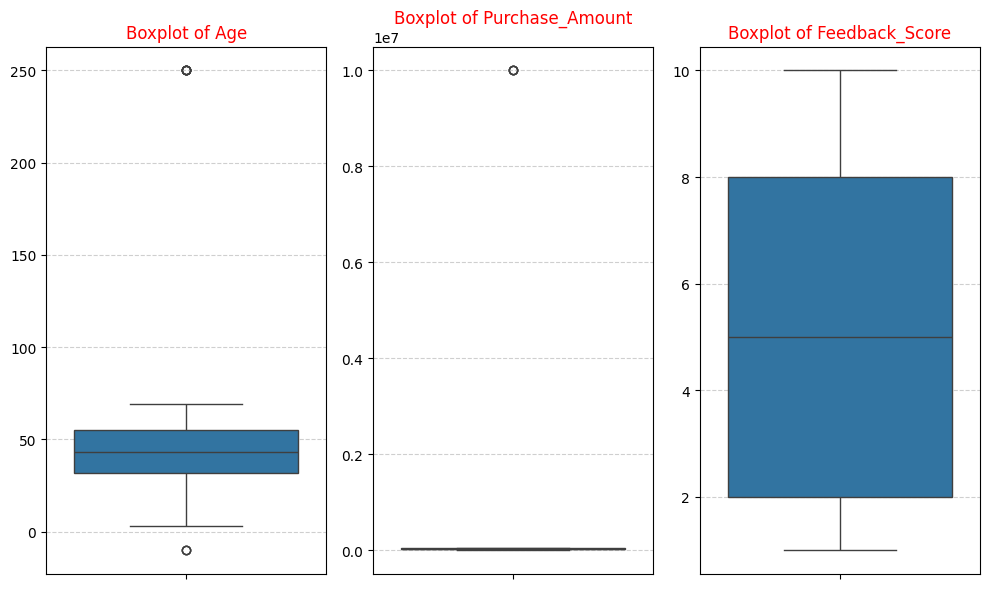

In [20]:
plt.figure(figsize=(10,6))
cols = ['Age','Purchase_Amount','Feedback_Score']
for x, col in enumerate(cols):
    plt.subplot(1,3,x+1)
    sns.boxplot(y = col, data = CustomerClean)
    plt.title(f'Boxplot of {col}', fontsize=12,color = 'red')
    plt.ylabel('')
    plt.grid(axis = 'y',linestyle = '--', alpha = 0.6)
   
plt.tight_layout()
plt.show()    


In [21]:
cols = ['Age','Purchase_Amount']
Q1 = CustomerClean[cols].quantile(0.25)
Q3 = CustomerClean[cols].quantile(0.75)
IQR = Q3-Q1
MinRange = Q1 - 1.5 * IQR
MaxRange = Q3 + 1.5 * IQR
outliers = ((CustomerClean[cols]<MinRange) | (CustomerClean[cols]> MaxRange)).any(axis=1)


In [22]:
CustomerClean = CustomerClean[~outliers]

In [23]:
outliers.sum()

np.int64(14)

In [24]:
CustomerClean.shape

(8986, 12)

In [25]:
AgeMax = CustomerClean['Age'].max()
AgeMin = CustomerClean['Age'].min()
print(AgeMax,AgeMin)

69 3


In [26]:
AmountMax = CustomerClean['Purchase_Amount'].max()
AmountMin = CustomerClean['Purchase_Amount'].min()
print(AmountMax,AmountMin)

49992.0 -500.0


In [27]:
#fix minium values
CustomerClean = CustomerClean[
    (CustomerClean['Purchase_Amount'] != -500) &
    (CustomerClean['Age'] >= 18)
]

AmountMin = CustomerClean['Purchase_Amount'].min()
AgeMin = CustomerClean['Age'].min()

print(AmountMin)
print(AgeMin)

0.0
18


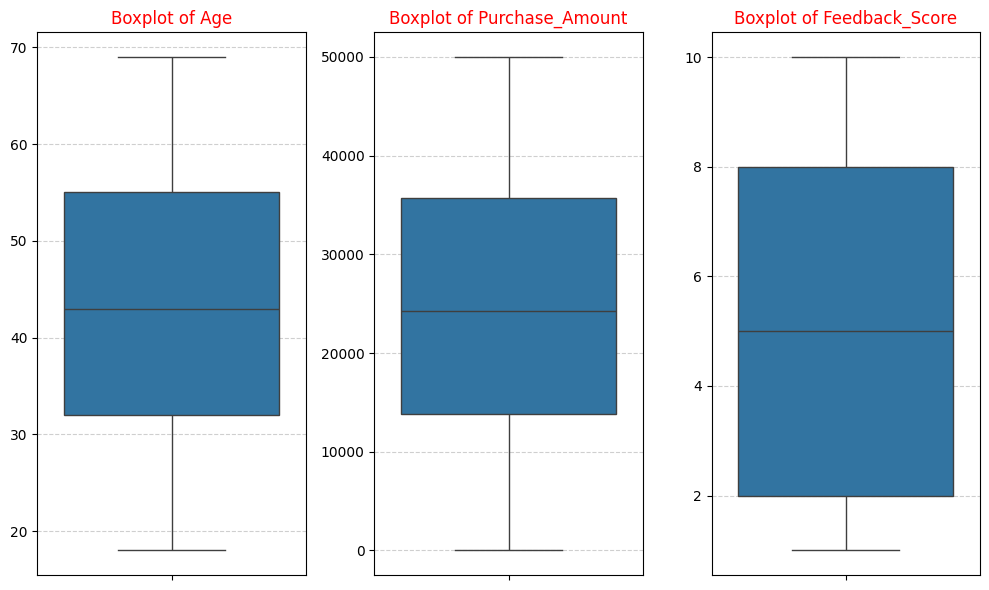

In [28]:
plt.figure(figsize=(10,6))
cols = ['Age','Purchase_Amount','Feedback_Score']
for x, col in enumerate(cols):
    plt.subplot(1,3,x+1)
    sns.boxplot(y = col, data = CustomerClean)
    plt.title(f'Boxplot of {col}', fontsize=12,color = 'red')
    plt.ylabel('')
    plt.grid(axis = 'y',linestyle = '--', alpha = 0.6)
   
plt.tight_layout()
plt.show()    


In [29]:
def AgeGroup(Age):
    if Age>=18 and Age<35:
        return 'Young'
    else:
        return 'Old'
CustomerClean['Age_Group'] = CustomerClean['Age'].apply(lambda x: AgeGroup(x))   

**Exploratory Data Analysis & Visualizations**


In [30]:
CustomerClean.describe()

,Age,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Phone_Number
count,8978.000000,8978,8978,8978.000000,8978.000000,8.978000e+03
mean,43.446313,2023-04-12 00:27:25.622633216,2025-04-08 10:19:26.050345472,24669.856427,5.139898,4.984145e+09
min,18.000000,2020-10-08 00:00:00,2024-10-08 00:00:00,0.000000,1.000000,9.208990e+05
25%,32.000000,2022-01-17 00:00:00,2025-01-07 00:00:00,13867.500000,2.000000,2.449466e+09
50%,43.000000,2023-04-05 00:00:00,2025-04-10 00:00:00,24268.000000,5.000000,5.000944e+09
75%,55.000000,2024-07-11 18:00:00,2025-07-08 00:00:00,35668.500000,8.000000,7.514655e+09
max,69.000000,2025-10-08 00:00:00,2025-10-08 00:00:00,49992.000000,10.000000,9.994402e+09
std,14.173233,NaN,NaN,13613.473234,2.909735,2.902189e+09


In [31]:
#Summary Statistics for Numerical Columns
cols = ['Age','Purchase_Amount','Feedback_Score']
Summary = CustomerClean[cols].describe().T
Summary['median'] = CustomerClean[cols].median()
Summary['IQR'] = Summary['75%'] - Summary['25%']
Summary['skewness'] = CustomerClean[cols].skew()
print('Numeric Summary Statistics:\n')
Summary

Numeric Summary Statistics:



,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
Age,8978.0,43.446313,14.173233,18.0,32.0,43.0,55.0,69.0,43.0,23.0,0.016055
Purchase_Amount,8978.0,24669.856427,13613.473234,0.0,13867.5,24268.0,35668.5,49992.0,24268.0,21801.0,0.050297
Feedback_Score,8978.0,5.139898,2.909735,1.0,2.0,5.0,8.0,10.0,5.0,6.0,0.187754


## Meaningful Insights from Numeric Summary Statistics

- The average customer age is approximately 43.45 years, with the median age at 43, indicating that the customer base is centered around middle-aged adults. This suggests that the business is primarily serving working-age consumers rather than a younger demographic.
- The age distribution is fairly balanced around the middle, with a relatively low skewness value of 0.016, which means age is distributed close to symmetric. This indicates a stable and well-spread customer base across the age range.
- Purchase Amount has a mean of about 24,669 and a median of 24,268, showing that most customers spend within a narrow band around the midpoint. The similarity between mean and median suggests the spending pattern is fairly consistent without a strong bias toward very high or very low values.
- The high maximum purchase value indicates the presence of a premium or high-value customer segment. These higher-value transactions can be targeted for loyalty campaigns, upselling, and personalized offers.
- Feedback Score has a mean of 5.14 and a median of 5.00, which shows that customer satisfaction ratings are generally moderate to positive. The low skewness indicates there is no strong tendency toward extremely high or extremely low ratings.
- Since the IQR for Feedback Score is 6.0, most customers rate the service between 2 and 8, with a central tendency around 5. This suggests that satisfaction is acceptable overall but there is room for improvement in product quality, service experience, or customer support.
- Overall, the business has a stable customer base with moderate spending and average satisfaction levels. The strongest opportunity lies in converting high-value segments and improving the lower end of the satisfaction range to increase retention and revenue.


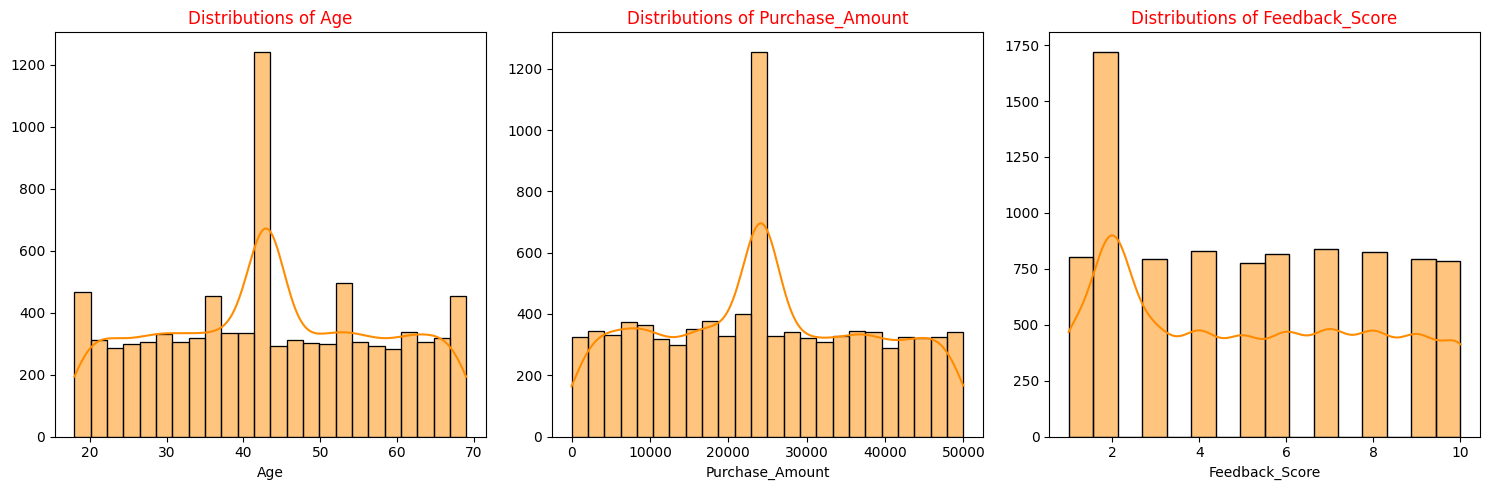

In [32]:
# Distribution of Numerical Columns
plt.figure(figsize=(15,5))
cols = ['Age','Purchase_Amount','Feedback_Score']
for x, col in enumerate(cols):
    plt.subplot(1,3,x+1)
    sns.histplot(x= col, data = CustomerClean, color = '#FF8C00', kde = True)
    plt.title(f'Distributions of {col}', fontsize=12,color = 'red')
    plt.ylabel('')
   
plt.tight_layout()
plt.show()

## Meaningful Insights


## Key Insights from the Customer Sales Analysis

- The age distribution is mostly concentrated in the 30–50 range, which suggests that the business is primarily serving working-age adults. This is a strong indicator of the main customer segment and helps guide marketing and product targeting.

- Purchase amounts are moderately distributed with a noticeable concentration in the mid-range, while a smaller number of customers spend significantly more. This indicates that most customers are regular buyers, but a high-value segment exists that may deserve loyalty-based offers and premium promotions.

- Feedback scores are generally centered around the middle to higher range, showing that customer satisfaction is positive overall. However, the existence of some lower scores suggests there is still room to improve service quality, delivery experience, or product satisfaction.

- The data shows relatively few extreme outliers after cleaning, which suggests a stable and consistent customer buying pattern. This is a positive sign for sales forecasting and operational planning.

- The strongest business opportunity lies in understanding which age groups, cities, or customer segments contribute the most to purchase value. Targeted campaigns can help increase repeat purchases and maximize revenue from the most valuable customers.

- Overall, the dataset reflects a healthy customer base with steady spending behavior and generally positive satisfaction levels. Improving retention strategies for moderate spenders and upselling to high-value customers can further improve revenue growth.




 Frequency of Gender:
 Gender
Male      4952
Female    4026
Name: count, dtype: int64


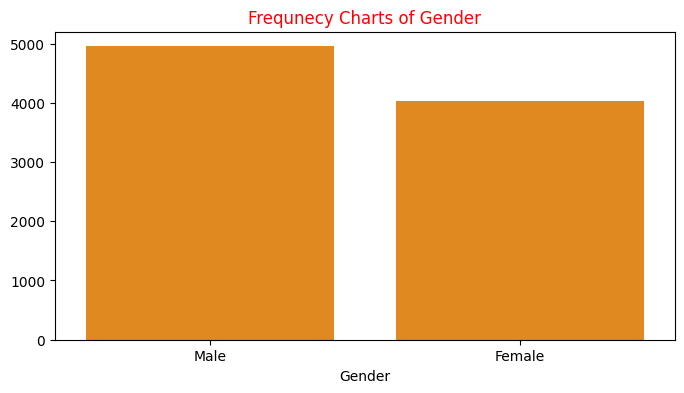


 Frequency of City:
 City
Kolkata      2250
Mumbai       1358
Chennai      1352
Delhi        1347
Hyderabad    1337
Bangalore    1334
Name: count, dtype: int64


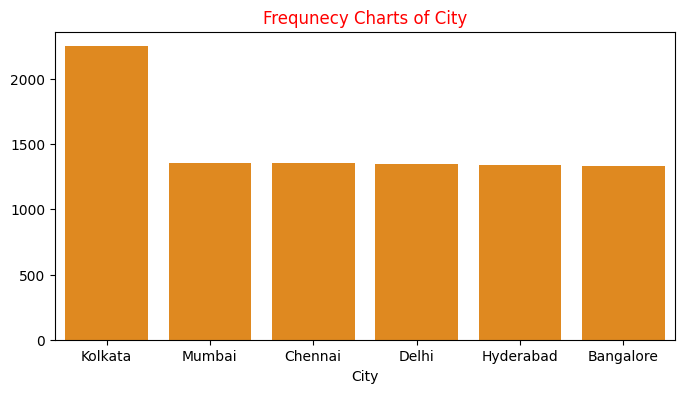


 Frequency of Age_Group:
 Age_Group
Old      6355
Young    2623
Name: count, dtype: int64


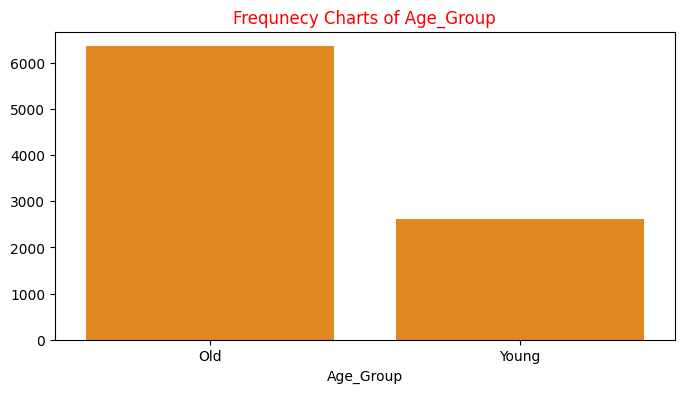

In [33]:
# Frequency of Categorical Columns
CatCols = ['Gender','City','Age_Group']
cols = ['Age','Purchase_Amount','Feedback_Score']
for x, col in enumerate(CatCols):
    print(f'\n Frequency of {col}:\n', CustomerClean[col].value_counts())
    plt.figure(figsize=(8,4))
    sns.countplot(x= col, data = CustomerClean, color = '#FF8C00',
    order=CustomerClean[col].value_counts().index)
    plt.title(f'Frequnecy Charts of {col}', fontsize=12,color = 'red')
    plt.ylabel('')
    plt.show()

## Meaningful Insights from Categorical Frequency Charts

- **Gender:** The number of male customers is higher than the number of female customers. This indicates that the current customer base is male-dominated, so the business should continue serving this segment while also exploring campaigns that improve engagement among female customers.

- **City:** Kolkata has the highest customer frequency by a clear margin. Mumbai, Chennai, Delhi, Hyderabad, and Bangalore have much smaller but fairly similar customer counts. This suggests that customer demand is geographically concentrated, making Kolkata the strongest market for localized promotions and focused inventory planning.

- **Age group:** The **Old** age group is substantially larger than the **Young** age group. The business is therefore mainly reaching customers aged 35 and above, creating an opportunity to strengthen retention and loyalty programs for this established segment while developing targeted offers to attract younger customers.

- **Overall business implication:** The customer base is concentrated by gender, location, and age. Marketing, stock allocation, and customer-retention strategies should prioritize the largest existing segments, while separate acquisition campaigns can be used to expand in underrepresented cities and age groups.


 Date Range for Signup_Date: 2020-10-08 00:00:00 to 2025-10-08 00:00:00
Time span: 1826 days

 Date Range for Last_Purchase_Date: 2024-10-08 00:00:00 to 2025-10-08 00:00:00
Time span: 365 days


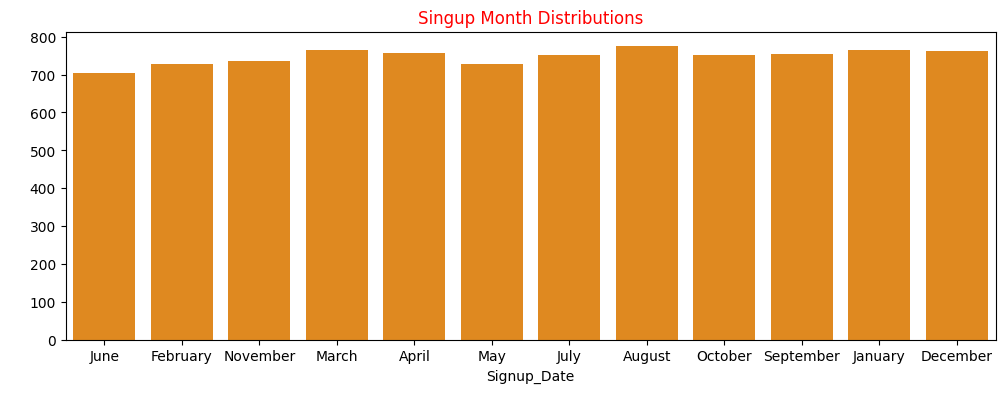

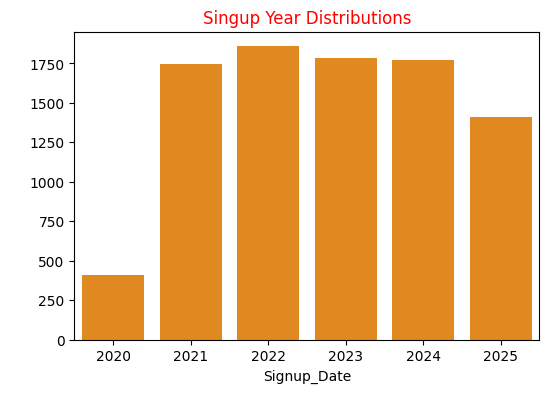

In [34]:
# Date Distributions
DateCols = ['Signup_Date','Last_Purchase_Date']

for col in DateCols:
    print(f'\n Date Range for {col}: {CustomerClean[col].min()} to {CustomerClean[col].max()}')
    print(f'Time span: {(CustomerClean[col].max() - CustomerClean[col].min()).days} days')

# Month Distribution    
plt.figure(figsize=(12,4)) 
sns.countplot(x = CustomerClean['Signup_Date'].dt.month_name(), color =  '#FF8C00', ) 
plt.title('Singup Month Distributions', color = 'red', fontsize = 12)
plt.ylabel(' ')
plt.show() 

#Year Distribution
plt.figure(figsize=(6,4)) 
sns.countplot(x = CustomerClean['Signup_Date'].dt.year, color =  '#FF8C00', ) 
plt.title('Singup Year Distributions', color = 'red', fontsize = 12)
plt.ylabel(' ')
plt.show()

## Meaningful Insights from Date Distributions

- **Signup period:** Customer signup dates span from October 2020 to October 2025, covering approximately five years. This provides a useful time window for observing changes in customer acquisition.

- **Signup by year:** Customer signups increased sharply from 2020 to 2021 and reached their highest level in 2022. Signup counts remained strong in 2023 and 2024, while 2025 shows a noticeable decline. Because the data ends in October 2025, the lower 2025 count may reflect an incomplete year rather than a definite fall in customer acquisition.

- **Signup by month:** Monthly signup counts are relatively consistent, with August showing the highest volume and June showing the lowest. The small difference between most months suggests that customer acquisition is fairly steady throughout the year and is not heavily dependent on one particular season.

- **Recent purchase activity:** Last purchase dates range from October 2024 to October 2025, indicating that the dataset mainly captures customers' activity during the most recent year. This supports recent engagement analysis, but it limits conclusions about long-term purchasing behavior.

- **Business implication:** The strong signup performance from 2021 to 2024 suggests effective customer acquisition during those years. The business should investigate the factors behind the 2022 peak, maintain consistent year-round campaigns, and monitor 2025 results after a complete year of data becomes available.

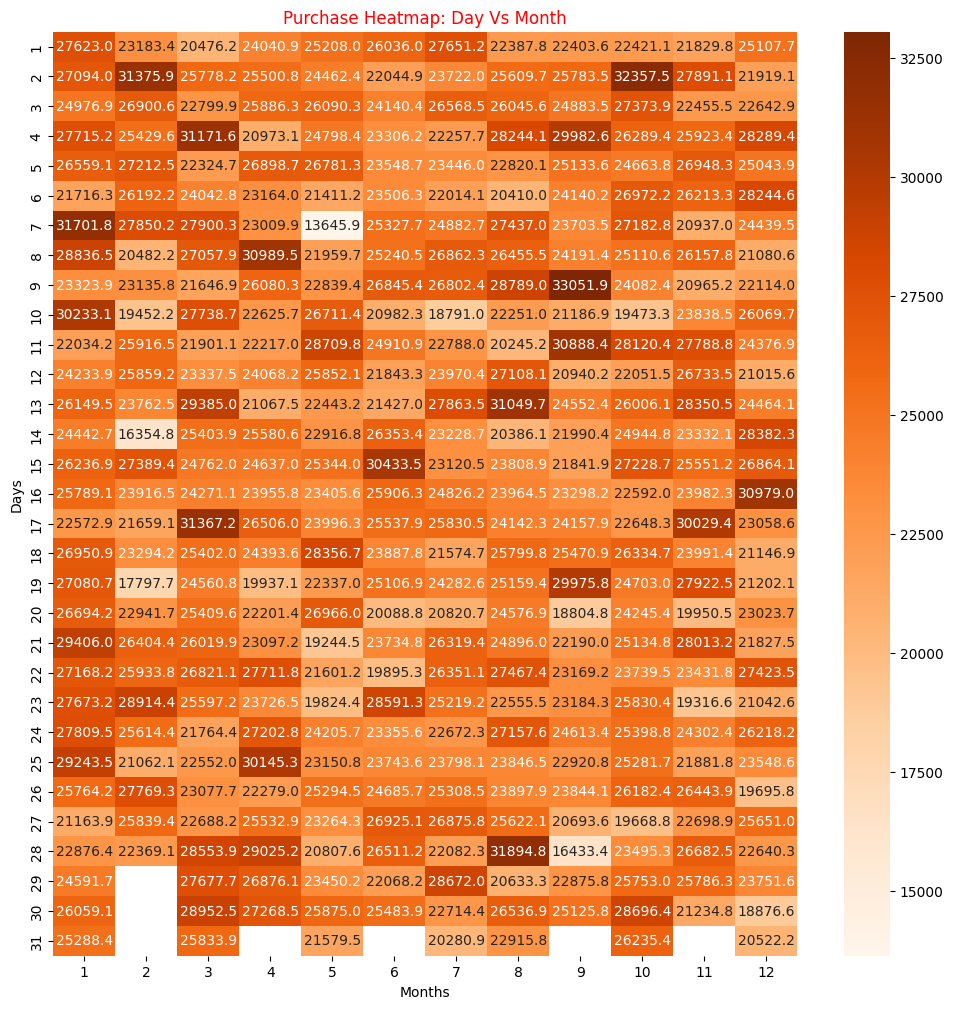

In [35]:
# Heatmap Distribution of Months Vs Days
heatmapData = CustomerClean.pivot_table(index = CustomerClean['Last_Purchase_Date'].dt.day,
columns = CustomerClean['Last_Purchase_Date'].dt.month,
 values= 'Purchase_Amount', aggfunc='mean' )
plt.figure(figsize = (12,12))
sns.heatmap(heatmapData, cmap = 'Oranges', fmt = '.1f', annot = True)
plt.title('Purchase Heatmap: Day Vs Month',fontsize = 12, color = 'red')
plt.xlabel('Months')
plt.ylabel('Days')
plt.show()

## Meaningful Insights from the Purchase Amount Heatmap

- The average purchase amount changes across different day-and-month combinations, indicating that customer spending is not uniform throughout the year.
- The strongest spending pocket appears around **11 September**, where the average purchase amount is approximately **33,052**. Other relatively high values occur around **7 January**, **4 March**, and **16 September**.
- Some of the lowest averages occur toward the end of certain months, such as around **28 September** and **29 February**. These lower values may reflect a small number of transactions, so they should not be treated as a definite decline in customer spending.
- Blank cells represent day-and-month combinations with no recorded transactions; they indicate missing activity rather than zero purchase amount.
- The heatmap does not show one consistently strongest month. The business should therefore compare these averages with transaction counts and monthly revenue before planning promotions or inventory changes.
- **Business implication:** High-value dates can be investigated for targeted offers and staffing, while additional data is needed to confirm whether the observed peaks are recurring seasonal patterns or isolated customer behavior.

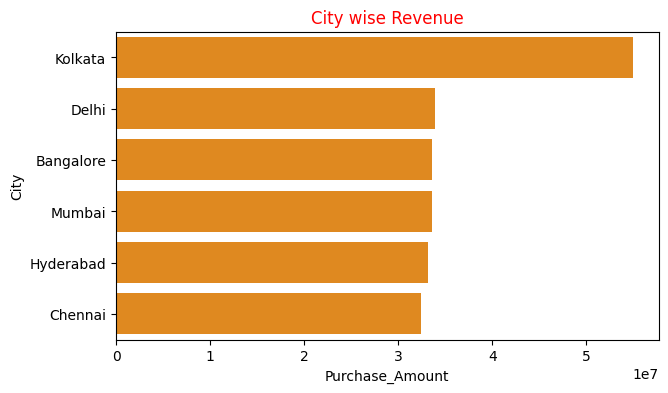

In [36]:
#City wise Revenue
CityRevenue = CustomerClean.groupby('City')['Purchase_Amount'].sum().reset_index()
CityRevenue = CityRevenue.sort_values(by = 'Purchase_Amount', ascending=False)
plt.figure(figsize=(7,4))
sns.barplot(y= CityRevenue['City'], x = CityRevenue['Purchase_Amount'], color = '#FF8C00')
plt.title('City wise Revenue', fontsize = 12, color = 'red')
plt.show()

## Meaningful Insights from City-wise Revenue

- **Kolkata** generates the highest revenue by a wide margin, making it the strongest market in the dataset and the most important city for revenue retention.
- **Delhi, Bangalore, Mumbai, and Hyderabad** produce similar revenue levels, showing a relatively balanced middle-performing group rather than one clear second-place market.
- **Chennai** records the lowest revenue among the six cities, which may indicate lower customer demand, fewer customers, lower average purchase amounts, or a combination of these factors.
- Kolkata's revenue is substantially higher than the other cities, so the business should protect its customer base there through reliable service, inventory availability, and loyalty campaigns.
- The lower-performing cities should not be judged only by total revenue. Comparing customer count, average purchase amount, and revenue per customer will help identify whether the opportunity is to acquire more customers or increase existing customer spending.
- **Business implication:** Continue strong operations in Kolkata while testing targeted promotions and customer-acquisition campaigns in Chennai and the other mid-performing cities.

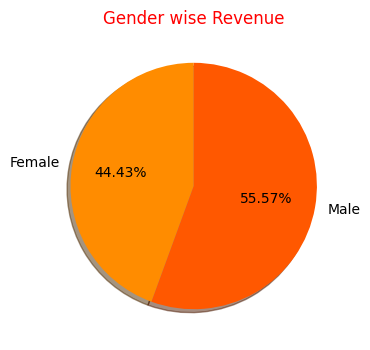

In [37]:
# Gender Wise Revenue
GenderRevenue = CustomerClean.groupby('Gender')['Purchase_Amount'].sum().reset_index()
plt.figure(figsize = (6,4))
plt.pie(GenderRevenue['Purchase_Amount'], labels=GenderRevenue['Gender'], 
colors = ['#FF8C00','#FF5800'],
autopct = '%1.2f%%', startangle = 90, shadow = True)
plt.title('Gender wise Revenue', color = 'red', fontsize = 12)
plt.show()


## Meaningful Insights from Gender-wise Revenue

- **Male customers contribute 55.57% of total revenue**, while **female customers contribute 44.43%**.
- Male-generated revenue is approximately **11.14 percentage points higher** than female-generated revenue, showing a moderate revenue difference rather than an extreme imbalance.
- The result indicates that male customers currently have a slightly greater contribution to sales, but female customers still represent a substantial share of total revenue.
- Revenue share alone cannot show whether the difference is caused by a larger number of male customers, higher average purchase amounts, or more frequent purchases. These measures should be compared before making marketing decisions.
- **Business implication:** Continue engaging the existing male customer segment while developing targeted campaigns and personalized offers to increase female customer participation and overall revenue.

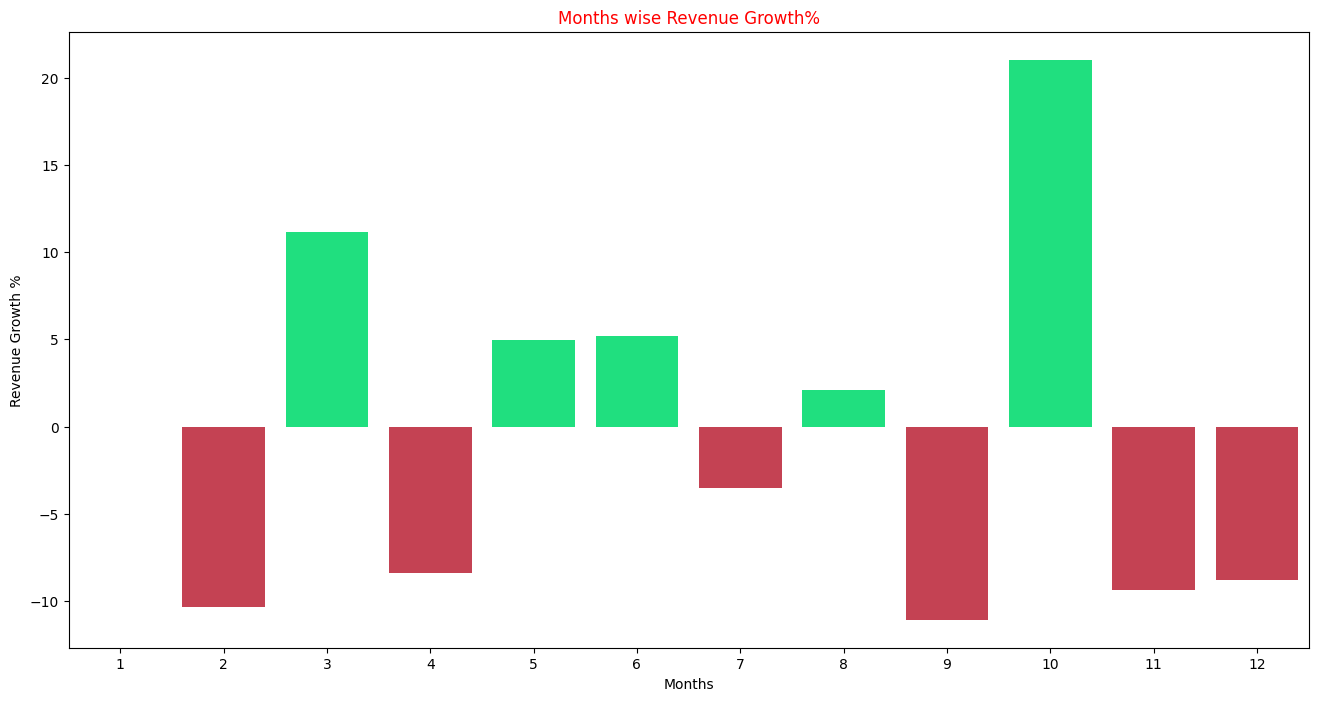

In [38]:
# Monthly purchase Growth%
purchase_Date = CustomerClean.sort_values(by = 'Last_Purchase_Date')
purchase_Months = (purchase_Date.groupby(purchase_Date['Last_Purchase_Date'].dt.month)
['Purchase_Amount'].sum().reset_index())
purchase_Months['MonthlyGrowth%'] = round(((purchase_Months['Purchase_Amount'] - 
purchase_Months['Purchase_Amount'].shift(1))/
purchase_Months['Purchase_Amount'].shift(1))*100,2)
purchase_Months["Growth_Type"] = purchase_Months["MonthlyGrowth%"].apply(
    lambda x: "Negative" if x < 0 else "Positive"
)
plt.figure(figsize=(16,8))
sns.barplot(
    x=purchase_Months['Last_Purchase_Date'],
    y=purchase_Months['MonthlyGrowth%'],
    hue=purchase_Months["Growth_Type"],
    palette={
        "Negative": "#DA2C43",
        "Positive": "#00FF7F"
    },
    legend=False
)
plt.xlabel("Months")
plt.ylabel("Revenue Growth %")
plt.title("Months wise Revenue Growth%", fontsize=12, color="red")

plt.show()


## Meaningful Insights from Monthly Revenue Growth

- Monthly revenue growth shows how total purchase revenue changed compared with the previous month. Positive bars represent month-over-month revenue increases, while negative bars represent declines.
- The chart shows noticeable fluctuations in monthly performance rather than a steady upward trend. This suggests that revenue is affected by changing customer demand, purchase frequency, or seasonal factors.
- The largest positive growth occurs around month 10, indicating a strong rise in revenue compared with month 9. This period should be investigated for successful campaigns, increased customer activity, or other business factors that may have contributed to the improvement.
- The largest decline occurs around month 9, followed by a strong recovery in month 10. This sharp reversal suggests that the business may experience short-term volatility and should compare transaction counts and average purchase values for both months.
- Several months record negative growth, including months 2, 4, 7, 9, 11, and 12. These declines may indicate weaker demand or lower purchasing activity and should be examined alongside customer count, marketing activity, and product availability.
- The first month has no previous month for comparison, so its growth value is undefined and should not be interpreted as a genuine positive change. For more accurate reporting, the first month should be excluded from the growth chart or labeled as unavailable.
- Because the calculation groups by month number, it combines the same month across different years if the dataset spans multiple years. A year-month grouping would provide a more precise chronological trend when multi-year data is available.
- **Business implication:** Investigate the causes of the sharp decline and recovery, repeat the actions associated with strong-growth months, and use monthly transaction counts and average purchase amounts to distinguish demand changes from changes in customer spending.

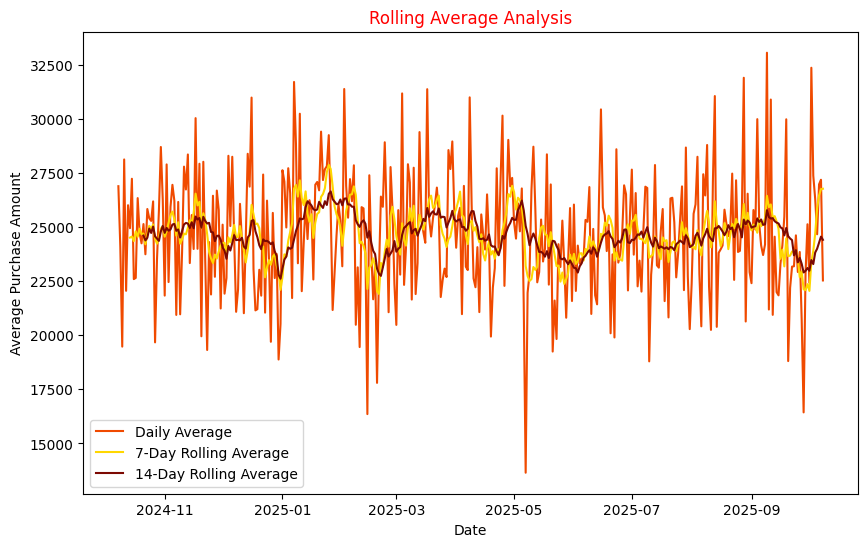

In [39]:
# Rolling Analysis
DailyRevenue = (
    CustomerClean
    .groupby('Last_Purchase_Date')['Purchase_Amount']
    .mean()
    .round(2)
    .reset_index()
)

DailyRevenue['rolling_7'] = (
    DailyRevenue['Purchase_Amount']
    .rolling(window=7)
    .mean()
)

DailyRevenue['rolling_14'] = (
    DailyRevenue['Purchase_Amount']
    .rolling(window=14)
    .mean()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    x=DailyRevenue['Last_Purchase_Date'],
    y=DailyRevenue['Purchase_Amount'],
    label='Daily Average', color = '#F04A00'
)

sns.lineplot(
    x=DailyRevenue['Last_Purchase_Date'],
    y=DailyRevenue['rolling_7'],
    label='7-Day Rolling Average', color = '#FFD700'
)

sns.lineplot(
    x=DailyRevenue['Last_Purchase_Date'],
    y=DailyRevenue['rolling_14'],
    label='14-Day Rolling Average', color = '#7C0902'
)

plt.xlabel('Date')
plt.ylabel('Average Purchase Amount')
plt.title('Rolling Average Analysis', fontsize=12, color='red')
plt.legend()
plt.show()

## Meaningful Insights from Rolling Average Analysis

- The daily purchase average fluctuates noticeably over time, which suggests that customer spending is not stable from day to day and may be influenced by demand, promotions, or seasonality.
- The 7-day rolling average smooths out short-term spikes and dips, helping to reveal the underlying sales trend more clearly than the raw daily values.
- The 14-day rolling average is even smoother and provides a more stable view of medium-term performance, indicating whether the business is generally trending upward, downward, or remaining stable.
- Periods of sharp increases in the daily average are likely tied to stronger sales activity, higher-value orders, or successful campaigns, while sudden drops can point to weaker demand or lower transaction volume.
- The rolling lines move together for much of the timeline, but the short-term daily line shows more volatility, confirming that short-term fluctuations are common while the overall trend remains comparatively steady.
- The recent section of the chart suggests continued variation in spending behavior, so the business should monitor whether the observed higher values are sustained or only temporary spikes.
- Business implication: use the rolling averages for trend monitoring and forecasting, while investigating the peaks and dips to understand what drives unusually high or low sales periods.


In [40]:
CustomerClean.groupby('Age_Group')['Purchase_Amount'].mean().reset_index()

,Age_Group,Purchase_Amount
0,Old,24778.182848
1,Young,24407.403355


In [41]:
# TTest 
#Is there a significant difference in average Purchase Amount between Young and Old customers?
Old_Customers = CustomerClean[CustomerClean['Age_Group']=='Old']['Purchase_Amount']
Young_Customers = CustomerClean[CustomerClean['Age_Group']=='Young']['Purchase_Amount']
t_stat, p_value = st.ttest_ind(Old_Customers, Young_Customers, equal_var = False)
print('T-Test: Purchase Amount Difference Between Young and Old Customers:\n')
print(f"T-statistic: {t_stat:.2f}, P-value: {p_value:.2f}")
alpha = 0.05
if p_value < alpha:
    print("Reject H0")
    print("Average Amount is significantly different.")
else:
    print("Fail to reject H0")
    print("There is not enough evidence of a significant difference.")


T-Test: Purchase Amount Difference Between Young and Old Customers:

T-statistic: 1.17, P-value: 0.24
Fail to reject H0
There is not enough evidence of a significant difference.


## Meaningful Insights from T-Test Analysis

- The p-value is 0.24, which is greater than the significance level of 0.05, so we fail to reject the null hypothesis.
- This means there is no statistically significant difference in average purchase amount between young and old customer groups based on this dataset.
- Even though the raw spending values may differ slightly between the two groups, the difference is not strong enough to be considered meaningful from a statistical perspective.
- The business implication is that age alone may not be a strong driver of spending behavior in this customer base.
- Instead of focusing only on age, the company may benefit from analyzing other factors such as city, product category, customer loyalty, or purchase frequency to understand what really affects revenue.
